In [5]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [6]:
bloodtests = pd.read_csv('healthcare_dataset.csv')

In [7]:
bloodtests

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [8]:
bloodtests = bloodtests.drop(['Name','Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider','Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date'], axis = 1)

In [9]:
bloodtests['Gender'] = bloodtests['Gender'].map({'Female': 1, 'Male': 0})
bloodtests['Test Results'] = bloodtests['Test Results'].map({'Normal': 0, 'Inconclusive': 1, 'Abnormal': 2})

In [10]:
bloodtests.columns

Index(['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Medication',
       'Test Results'],
      dtype='object')

In [11]:
Medical_Condition_unique = np.unique(bloodtests[['Medical Condition']])
Blood_Type_unique = np.unique(bloodtests[['Blood Type']])
Medication_unique = np.unique(bloodtests[['Medication']])

In [12]:
for i in range(len(Medical_Condition_unique)):
    bloodtests[f'Medical_Condition_{Medical_Condition_unique[i]}'] = bloodtests['Medical Condition'].map({f'{Medical_Condition_unique[i]}': 1, '0': 0}).fillna(0)
for i in range(len(Blood_Type_unique)):
    bloodtests[f'Blood_Type_{Blood_Type_unique[i]}'] = bloodtests['Blood Type'].map({f'{Blood_Type_unique[i]}': 1, '0': 0}).fillna(0)
for i in range(len(Medication_unique)):
    bloodtests[f'Medication_{Medication_unique[i]}'] = bloodtests['Medication'].map({f'{Medication_unique[i]}': 1, '0': 0}).fillna(0)

In [13]:
bloodtests = bloodtests.drop(['Medical Condition', 'Blood Type', 'Medication'], axis = 1 )
bloodtests

,Age,Gender,Test Results,Medical_Condition_Arthritis,Medical_Condition_Asthma,Medical_Condition_Cancer,Medical_Condition_Diabetes,Medical_Condition_Hypertension,Medical_Condition_Obesity,Blood_Type_A+,...,Blood_Type_AB-,Blood_Type_B+,Blood_Type_B-,Blood_Type_O+,Blood_Type_O-,Medication_Aspirin,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
0,30,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,62,0,1,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,76,1,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,28,1,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,43,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,42,1,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
55496,61,1,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
55497,38,1,2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
55498,43,0,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [14]:

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import svm

list_col = bloodtests.drop(['Test Results'], axis=1).columns.to_list()

x = bloodtests.loc[:,list_col].to_numpy()
y = bloodtests.loc[:,['Test Results']].to_numpy().flatten()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

In [15]:
log = LogisticRegression().fit(x_train, y_train)
reg = LinearRegression().fit(x_train, y_train)
vector_1 = svm.SVC(C = 0.1).fit(x_train, y_train)
vector_2 = svm.SVC(C = 10).fit(x_train, y_train)


In [16]:
print('коробочные решения')
print('метрика обучения / теста для:')
print(f'линейная регрессия: {round(reg.score(x_train, y_train), 2)} / {round(reg.score(x_test, y_test), 2)}')
print(f'логистическая регрессия: {round(log.score(x_train, y_train), 2)} / {round(log.score(x_test, y_test), 2)}')
print(f'метод опорных векторов с параметром С = 0.1: {round(vector_1.score(x_train, y_train), 2)} / {round(vector_1.score(x_test, y_test), 2)}')
print(f'метод опорных векторов с параметром С = 10: {round(vector_2.score(x_train, y_train), 2)} / {round(vector_2.score(x_test, y_test), 2)}')

коробочные решения
метрика обучения / теста для:
линейная регрессия: 0.0 / -0.0
логистическая регрессия: 0.34 / 0.34
метод опорных векторов с параметром С = 0.1: 0.34 / 0.34
метод опорных векторов с параметром С = 10: 0.34 / 0.34


In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score


X, y = make_classification(n_samples=1000, n_features=20, random_state=42)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),  
    activation='relu',              
    solver='adam',                  
    alpha=0.0001,                  
    batch_size=32,                  
    learning_rate='adaptive',      
    max_iter=500,                  
    random_state=42,
    verbose=True                   
)


mlp.fit(X_train_scaled, y_train)


y_pred = mlp.predict(X_test_scaled)


print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Iteration 1, loss = 0.60481353
Iteration 2, loss = 0.43680164
Iteration 3, loss = 0.35032105
Iteration 4, loss = 0.30958421
Iteration 5, loss = 0.29314393
Iteration 6, loss = 0.27562472
Iteration 7, loss = 0.26379476
Iteration 8, loss = 0.25076178
Iteration 9, loss = 0.24126664
Iteration 10, loss = 0.22910366
Iteration 11, loss = 0.21878655
Iteration 12, loss = 0.20789514
Iteration 13, loss = 0.20021555
Iteration 14, loss = 0.19203887
Iteration 15, loss = 0.18081232
Iteration 16, loss = 0.17059702
Iteration 17, loss = 0.16178771
Iteration 18, loss = 0.15411233
Iteration 19, loss = 0.14534542
Iteration 20, loss = 0.13698698
Iteration 21, loss = 0.13093364
Iteration 22, loss = 0.12402707
Iteration 23, loss = 0.11645449
Iteration 24, loss = 0.10749807
Iteration 25, loss = 0.10260590
Iteration 26, loss = 0.09184870
Iteration 27, loss = 0.08648324
Iteration 28, loss = 0.08101408
Iteration 29, loss = 0.07526323
Iteration 30, loss = 0.06859471
Iteration 31, loss = 0.06385907
Iteration 32, los

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np


iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


tree_clf = DecisionTreeClassifier(
    max_depth=3,           
    min_samples_split=2,  
    min_samples_leaf=1,    
    criterion='gini',     
    random_state=42
)

tree_clf.fit(X_train, y_train)



DecisionTreeClassifier(max_depth=3, random_state=42)

In [19]:
y_pred = tree_clf.predict(X_test)
y_pred_proba = tree_clf.predict_proba(X_test)


print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print(classification_report(y_test, y_pred, target_names=class_names))

print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


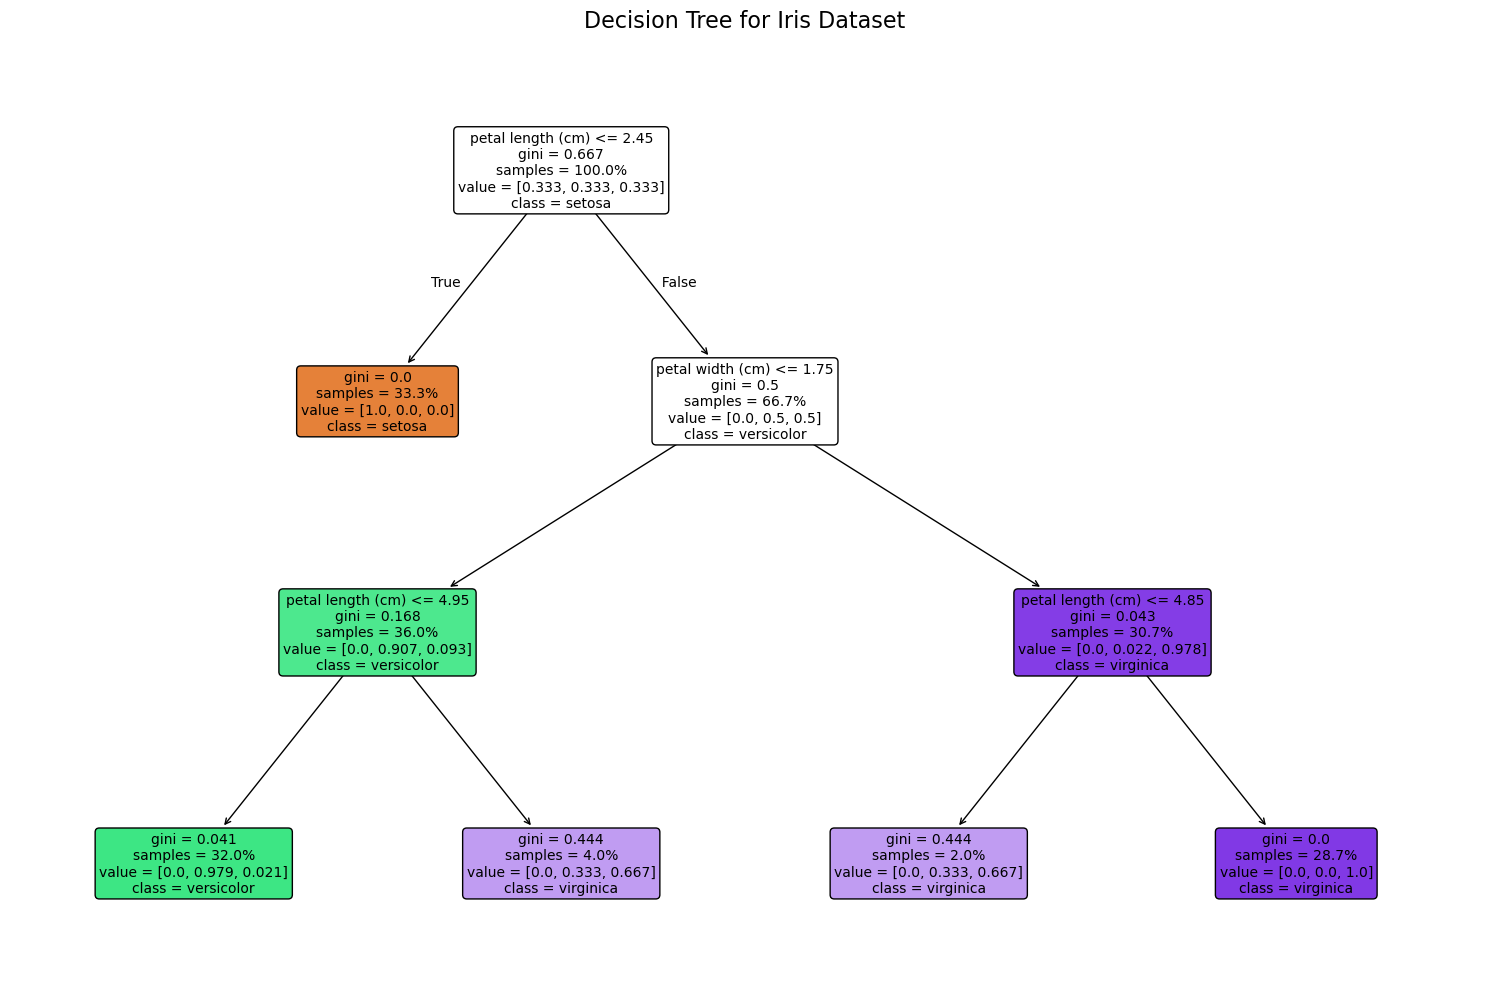

In [20]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np


iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names


tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X, y)


plt.figure(figsize=(15, 10))
plot_tree(tree_clf,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True)
plt.title("Decision Tree for Iris Dataset", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

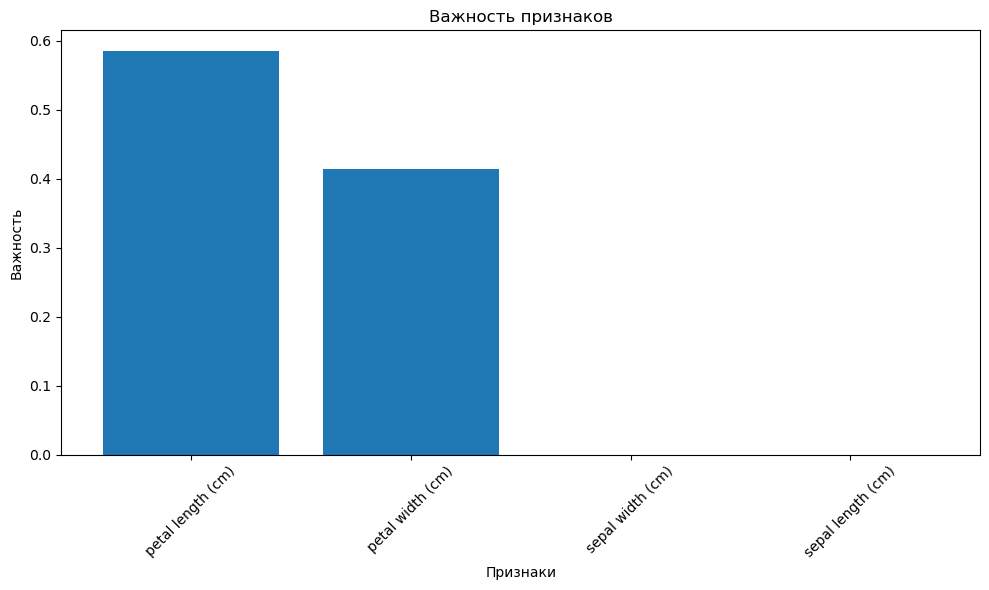

In [21]:
feature_importances = tree_clf.feature_importances_

plt.figure(figsize=(10, 6))
indices = np.argsort(feature_importances)[::-1]
plt.title("Важность признаков")
plt.bar(range(X.shape[1]), feature_importances[indices])
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.xlabel("Признаки")
plt.ylabel("Важность")
plt.tight_layout()
plt.show()



In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
rf_main = RandomForestRegressor(n_estimators=100, random_state=0)
rf_main.fit(X_train, y_train)


RandomForestRegressor(random_state=0)

In [23]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [24]:
from sklearn.metrics import r2_score
r2_xgb = r2_score(y_test, xgb_model.predict(X_test))
print(f"R² xgb: {r2_xgb:.4f}")

R² xgb: 0.9743


In [25]:
r2_rf = r2_score(y_test, rf_main.predict(X_test))
print(f"R² rf: {r2_rf:.4f}")

R² rf: 0.9990


In [26]:
from catboost import CatBoostRegressor
cb = CatBoostRegressor(n_estimators=100, learning_rate=0.1, verbose=False, random_state=42)
cb.fit(X_train, y_train)
r2_cb = r2_score(y_test, cb.predict(X_test))
print(f"Точность RF {r2_cb:.4f}")

Точность RF 0.9888


In [1]:
import lightgbm as lgb
lgbm = lgb.LGBMRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    min_child_samples=5,  
    num_leaves=15,       
    verbose=-1            
)
lgbm.fit(X_train, y_train)
r2_lgbm = r2_score(y_test, lgbm.predict(X_test))
print(f"Точность lgbm {r2_lgbm:.4f}")

NameError: name 'X_train' is not defined